# Step1(Input)
# Library Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

# And more required import

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


# Step2
# Some cnn Libraries(Layer creating)
# 1.Covolution
#2. Pooling

In [ ]:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

# Step3
# Some NN library Import(After classification flattening)


In [ ]:
from sklearn.linear_model import Perceptron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.utils import to_categorical

In [ ]:
df=pd.read_csv('mnist_train.csv')
df1=pd.read_csv('mnist_test.csv')

In [ ]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 785 columns data(as 28*28 pixel)
# above dataset-label=the number to predict
# pixel means= all pixel in the same image

In [ ]:
df.shape

(60000, 785)

In [ ]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [ ]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


# Preprocessing
# both for train and test data but parameters are learned from train data

In [ ]:
X_train=df.drop("label",axis=1)
y_train=df["label"]
X_test=df1.drop("label",axis=1)
y_test=df1["label"]

# Converting the dataset values in ratios with(0-255)

In [ ]:
Xtrain=X_train.astype("float32")/255.0
Xtest=X_test.astype("float32")/255.0

# Reshaping: so that the (Labels and it's pixels) comes within a block
# Think it of like previously all were in arrays now they are in a square like thing
# .Values=converting the dataset(which is in pandas Dataframe to Numpy Arrays)

In [ ]:
XTrain_img=X_train.values.reshape(-1,28,28)
XTest_img=X_test.values.reshape(-1,28,28)

In [ ]:
XTrain_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

# One hot encoding(coverting result column in(o's and 1's))

In [ ]:
Y_traincat=to_categorical(y_train,10)
Y_testcat=to_categorical(y_test,10)

# Perceptron model
# Flatten(will convert 28*28) to (785 inputs)
# Dense(output(0-9)that's why 10)

In [ ]:
perp=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax") # softmax for multiclass prediction
])

In [ ]:
perp.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

# Training and testing

In [ ]:
from sklearn.base import validate_data
history=perp.fit(XTrain_img,Y_traincat,epochs=5,
                 batch_size=32,validation_data=(XTest_img,Y_testcat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7175 - loss: 1.1236 - val_accuracy: 0.8801 - val_loss: 0.4837
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8745 - loss: 0.4784 - val_accuracy: 0.8944 - val_loss: 0.4019
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8887 - loss: 0.4152 - val_accuracy: 0.9009 - val_loss: 0.3688
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8949 - loss: 0.3807 - val_accuracy: 0.9044 - val_loss: 0.3505
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8999 - loss: 0.3593 - val_accuracy: 0.9082 - val_loss: 0.3380


In [ ]:
acc_perp=perp.evaluate(XTest_img,Y_testcat,verbose=0)[1]

In [ ]:
acc_perp

0.9082000255584717

# ANN in same
# more layers creating

In [ ]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

In [ ]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

#Train Test part

In [ ]:
history_ann=ann.fit(XTrain_img,Y_traincat,epochs=5,batch_size=32,validation_data=(XTest_img,Y_testcat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8796 - loss: 0.4203 - val_accuracy: 0.9625 - val_loss: 0.1227
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9679 - loss: 0.1059 - val_accuracy: 0.9686 - val_loss: 0.1019
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9776 - loss: 0.0696 - val_accuracy: 0.9728 - val_loss: 0.0849
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9838 - loss: 0.0532 - val_accuracy: 0.9756 - val_loss: 0.0860
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9867 - loss: 0.0402 - val_accuracy: 0.9757 - val_loss: 0.0794


In [ ]:
acc_ann=ann.evaluate(XTest_img,Y_testcat,verbose=0)[1]

In [ ]:
acc_ann

0.9757000207901001

# CNN
# Image Input(convolution,pooling)
# earlier it was (28,28)-(no channel) but for GREYSCALE (we have to change that (28,28,1)
# 1 means greyscale

In [ ]:
XTrain_imgcnn=X_train.values.reshape(-1,28,28,1)
XTest_imgcnn=X_test.values.reshape(-1,28,28,1)
#FOR greyscale

In [ ]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5), #prevent overfitting
    Dense(10,activation="softmax")
])

In [ ]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

#Training

In [ ]:
history_cnn=cnn.fit(XTrain_imgcnn,Y_traincat,epochs=5,batch_size=32,validation_data=(XTest_imgcnn,Y_testcat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8752 - loss: 0.4016 - val_accuracy: 0.9861 - val_loss: 0.0421
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9762 - loss: 0.0790 - val_accuracy: 0.9877 - val_loss: 0.0361
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9839 - loss: 0.0533 - val_accuracy: 0.9908 - val_loss: 0.0265
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9873 - loss: 0.0416 - val_accuracy: 0.9909 - val_loss: 0.0279
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 31ms/step - accuracy: 0.9903 - loss: 0.0330 - val_accuracy: 0.9924 - val_loss: 0.0226


In [ ]:
cnn_acc=cnn.evaluate(XTest_imgcnn,Y_testcat,verbose=0)[1]

In [ ]:
cnn_acc

0.9923999905586243

In [ ]:
num_samples = 5
random_indices = np.random.randint(0, len(XTest_imgcnn), num_samples)

sample_images = XTest_imgcnn[random_indices]
sample_actual_labels = y_true[random_indices]
sample_predicted_perp = y_pred_classes_perp[random_indices]
sample_predicted_ann = y_pred_classes_ann[random_indices]
sample_predicted_cnn = y_pred_classes_cnn[random_indices]

print(f"Selected {num_samples} sample images and their labels.")

Selected 5 sample images and their labels.


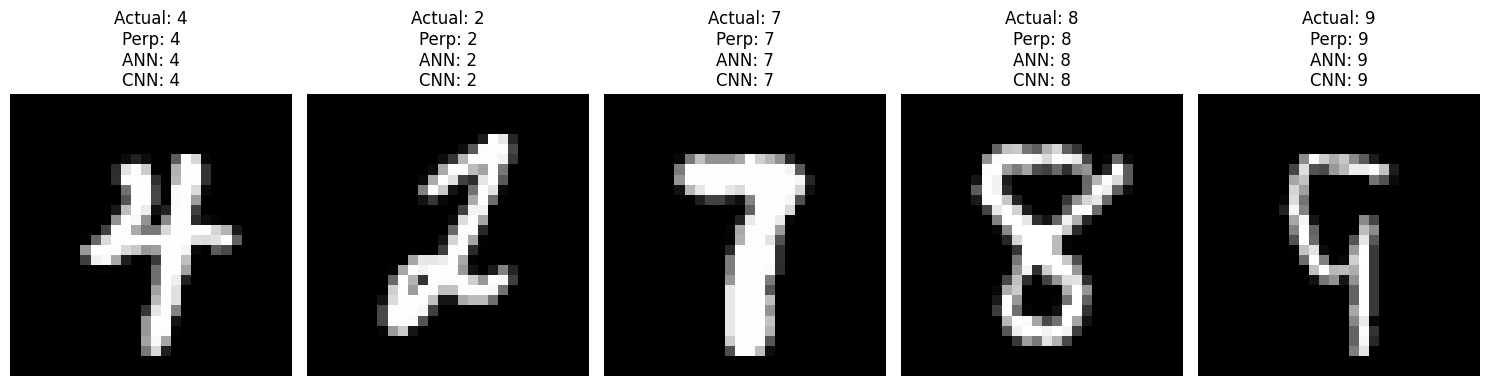

Displayed sample images with actual and predicted labels.


In [ ]:
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {sample_actual_labels[i]}\nPerp: {sample_predicted_perp[i]}\nANN: {sample_predicted_ann[i]}\nCNN: {sample_predicted_cnn[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
print("Displayed sample images with actual and predicted labels.")

# PLOTTING

In [ ]:
def plot_training(history,title):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history["accuracy"],label="Training")
  plt.plot(history.history["val_accuracy"],label="Validation")
  plt.title(f"{title} Accuracy")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(history.history["loss"],label="Training")
  plt.plot(history.history["val_loss"],label="Validation")
  plt.title(f"{title} Loss")

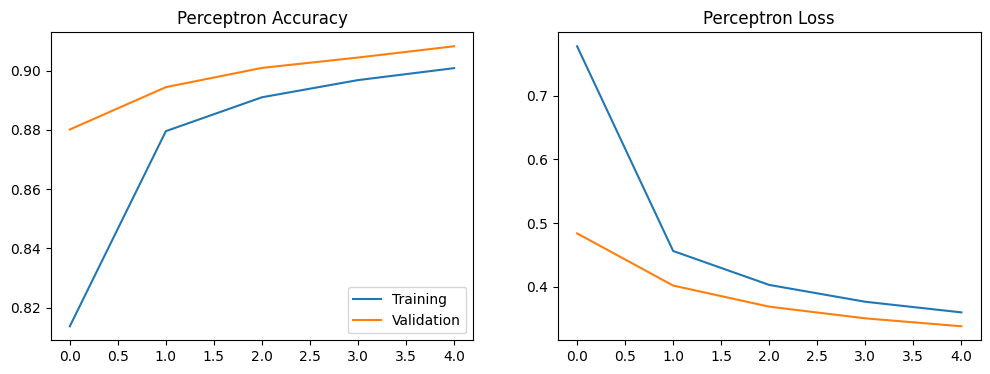

In [ ]:
plot_training(history,"Perceptron")

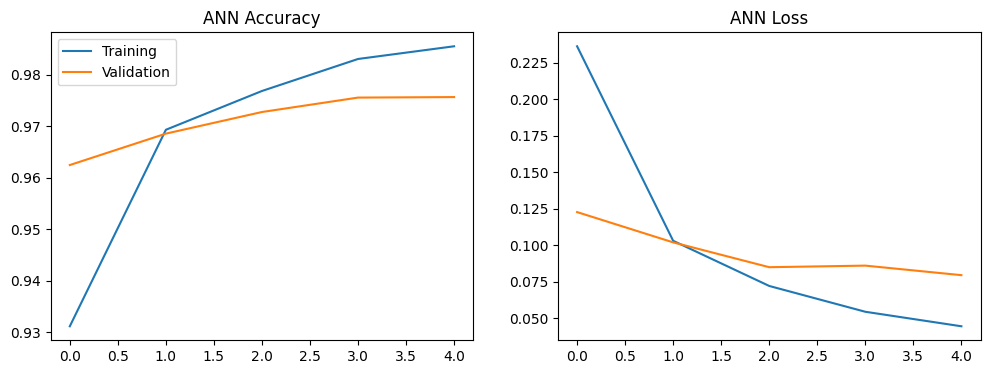

In [ ]:
plot_training(history_ann,"ANN")

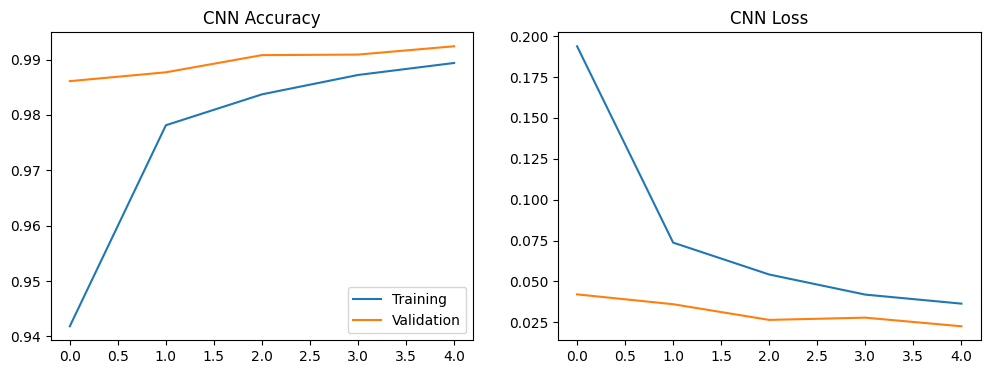

In [ ]:
plot_training(history_cnn,"CNN")

# Val_accuracy vs epochs

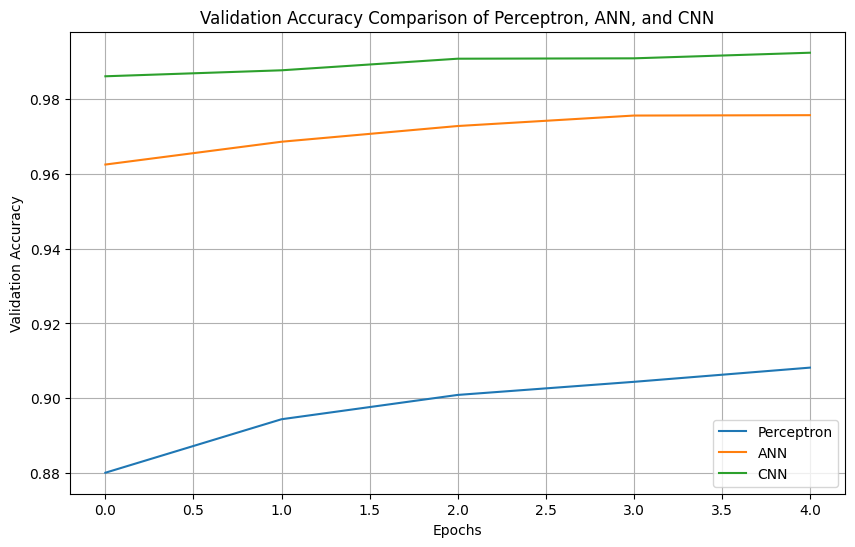

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Perceptron')
plt.plot(history_ann.history['val_accuracy'], label='ANN')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.title('Validation Accuracy Comparison of Perceptron, ANN, and CNN')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Val_loss vs epochs

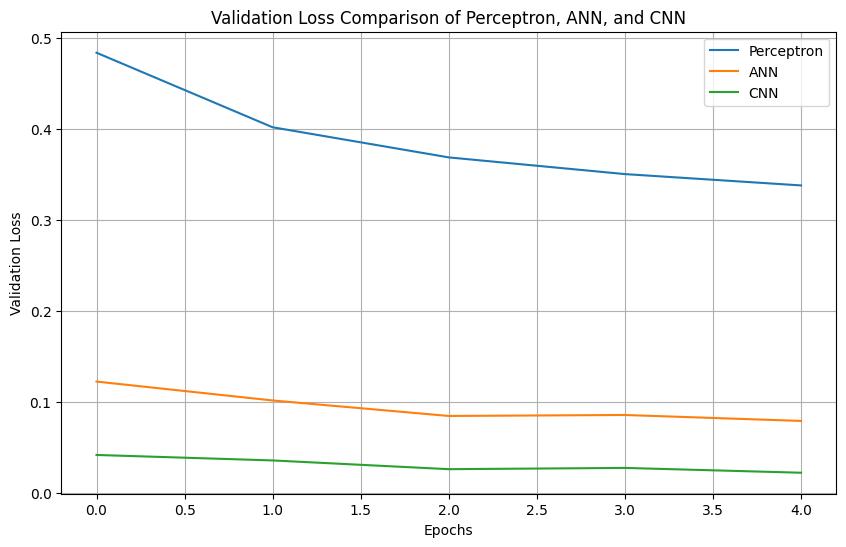

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_loss'], label='Perceptron')
plt.plot(history_ann.history['val_loss'], label='ANN')
plt.plot(history_cnn.history['val_loss'], label='CNN')
plt.title('Validation Loss Comparison of Perceptron, ANN, and CNN')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Get predictions for Perceptron model
y_pred_perp = perp.predict(XTest_img)
y_pred_classes_perp = np.argmax(y_pred_perp, axis=1)

# Get predictions for ANN model
y_pred_ann = ann.predict(XTest_img)
y_pred_classes_ann = np.argmax(y_pred_ann, axis=1)

# Get predictions for CNN model
y_pred_cnn = cnn.predict(XTest_imgcnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

# True labels for the test set
y_true = np.argmax(Y_testcat, axis=1)

print("Predictions generated for all models.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predictions generated for all models.


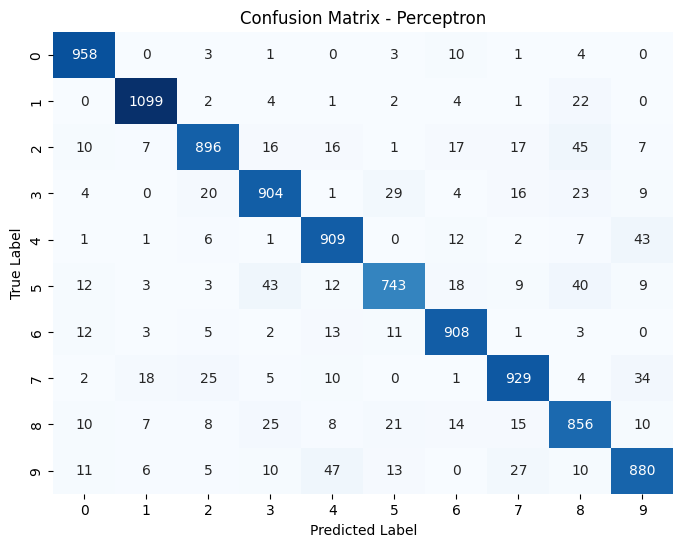

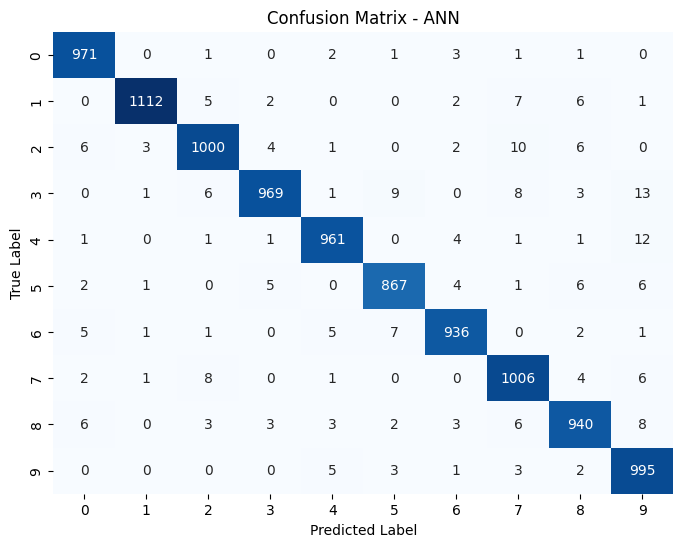

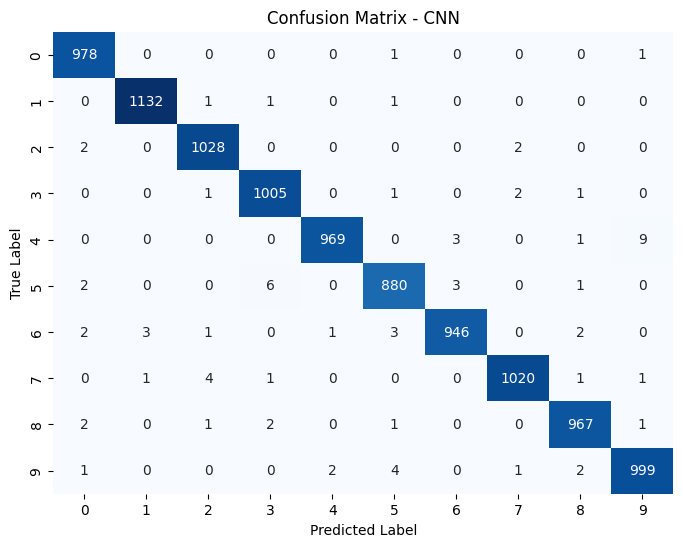

Confusion matrix heatmaps generated for Perceptron, ANN, and CNN models.


In [ ]:
# Calculate confusion matrices
cm_perp = confusion_matrix(y_true, y_pred_classes_perp)
cm_ann = confusion_matrix(y_true, y_pred_classes_ann)
cm_cnn = confusion_matrix(y_true, y_pred_classes_cnn)

# Plotting function for confusion matrix
def plot_confusion_matrix_heatmap(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Plot heatmaps for each model
plot_confusion_matrix_heatmap(cm_perp, "Perceptron")
plot_confusion_matrix_heatmap(cm_ann, "ANN")
plot_confusion_matrix_heatmap(cm_cnn, "CNN")

print("Confusion matrix heatmaps generated for Perceptron, ANN, and CNN models.")